In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'

from joblib import Parallel, delayed

from scipy.special import iv

import pickle

import schwingerModel as sim

In [2]:
m = .2
a = 1
dimx = 8
dimt = 8
totalSteps = 500

In [3]:
betas = np.linspace(.1,3,20)

sims = Parallel(n_jobs=-1)(delayed(sim.schwingerModel)(dimx=dimx,dimt=dimt, metroSteps=totalSteps,beta=betas[i], fMass=m, aSpacing=1,cgRtol=1e-5,tqdmPosition=i,numSubSteps=10) for i in range(len(betas)))

  0%|          | 0/500 [00:00<?, ?it/s]



  0%|          | 0/500 [00:00<?, ?it/s]




  0%|          | 0/500 [00:00<?, ?it/s]




  0%|          | 0/500 [00:00<?, ?it/s]






  0%|          | 0/500 [00:00<?, ?it/s]





  0%|          | 0/500 [00:00<?, ?it/s]












  0%|          | 0/500 [00:00<?, ?it/s]







  0%|          | 0/500 [00:00<?, ?it/s]


















  0%|          | 0/500 [00:00<?, ?it/s]













  0%|          | 0/500 [00:00<?, ?it/s]










  0%|          | 0/500 [00:00<?, ?it/s]











  0%|          | 0/500 [00:00<?, ?it/s]


















 ... (more hidden) ...














  0%|          | 0/500 [00:00<?, ?it/s]
















  0%|          | 0/500 [00:00<?, ?it/s]

















  1%|          | 4/500 [00:00<00:12, 39.60it/s]A















  1%|          | 4/500 [00:00<00:12, 39.62it/s]

  1%|          | 3/500 [00:00<00:16, 29.46it/s]


  1%|          | 4/500 [00:00<00:12, 39.03it/s]



  1%|          | 4/500 [00:00<00:12, 38.61it/

In [6]:
stats = []
for s in sims:
    stats.append(sim.analysis.plaqStats(s,burnIn=100))

stats = np.array(stats).T

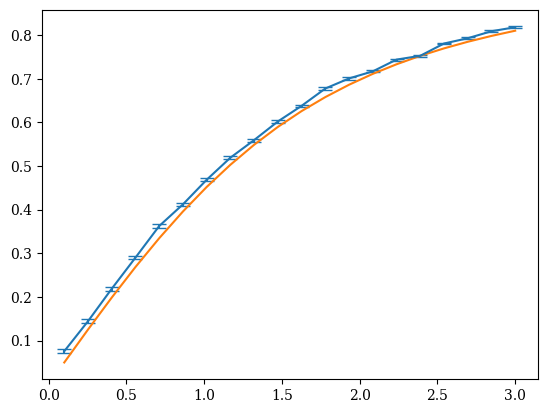

In [7]:
plt.errorbar(x=betas,y=stats[0],yerr=stats[1],capsize=5)
plt.plot(betas, iv(1,betas)/iv(0,betas))